# 1. Wczytanie bilbiotek i logów

In [1]:
from src.log_loader import load_logs
from src.audit_parser import parse_line
from config import RAW_LOG_PATH
from src.rules import run_all_rules

from src.preprocessing import detections_to_dataframe

logs = load_logs(RAW_LOG_PATH)
records = [parse_line(line) for line in logs]

print(f"Loaded {len(records)} records")

Loaded 51 records


# 2 Pierwsze 5 sparsowanych rekordów

In [2]:
for record in records[:5]:
    print(record)

LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='SYSCALL', user_id='1000', command='sudo', executable='/usr/bin/sudo', success=True, raw_message='type=SYSCALL msg=audit(1715671201.001:101): arch=c000003e syscall=59 success=yes exit=0 a0=55f1c2b3a2d0 a1=55f1c2b3a3f0 a2=55f1c2b3a4f0 items=2 ppid=1123 pid=1456 auid=1000 uid=1000 gid=1000 tty=pts0 ses=3 comm="sudo" exe="/usr/bin/sudo" key="priv_esc"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='EXECVE', user_id=None, command=None, executable=None, success=None, raw_message='type=EXECVE msg=audit(1715671201.001:101): argc=3 a0="sudo" a1="cat" a2="/etc/shadow"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='CWD', user_id=None, command=None, executable=None, success=None, raw_message='type=CWD msg=audit(1715671201.001:101): cwd="/home/lukasz"')
LogRecord(timestamp=datetime.datetime(2024, 5, 14, 9, 20, 1, 1000), event_type='PATH', user_id='0', 

# 3 Uruchomienie reguł

In [3]:
for record in records:
    detections = run_all_rules(record)
    if detections:
        print(record.raw_message)

        for detection in detections:
            print(detection)

        print()

type=PATH msg=audit(1715671201.001:101): item=0 name="/usr/bin/cat" inode=123456 dev=08:01 mode=0100755 ouid=0 ogid=0 nametype=NORMAL
[ALERT] Root Activity: Root user activity detected

type=PATH msg=audit(1715671201.001:101): item=1 name="/etc/shadow" inode=234567 dev=08:01 mode=0100400 ouid=0 ogid=0 nametype=NORMAL
[ALERT] Root Activity: Root user activity detected

type=USER_AUTH msg=audit(1715671202.112:102): pid=1789 uid=0 auid=4294967295 ses=4294967295 msg='op=PAM:authentication acct="lukasz" exe="/usr/sbin/sshd" hostname=192.168.1.50 addr=192.168.1.50 terminal=ssh res=success'
[ALERT] Root Activity: Root user activity detected

type=USER_ACCT msg=audit(1715671202.113:103): pid=1789 uid=0 auid=4294967295 ses=4294967295 msg='op=PAM:accounting acct="lukasz" exe="/usr/sbin/sshd" hostname=192.168.1.50 addr=192.168.1.50 terminal=ssh res=success'
[ALERT] Root Activity: Root user activity detected

type=PATH msg=audit(1715671203.221:104): item=0 name="/var/log/auth.log" inode=345678 dev

# 4 Statystyki

In [4]:
from collections import Counter

rule_counter = Counter()

total_logs = len(records)
anomaly_logs = 0

for record in records:

    detections = run_all_rules(record)

    if detections:
        anomaly_logs += 1

    for detection in detections:
        rule_counter[detection.rule_name] += 1

print(f"Total logs: {total_logs}")
print(f"Logs with anomalies: {anomaly_logs}")
print(f"Normal logs: {total_logs - anomaly_logs}")

rule_counter

Total logs: 51
Logs with anomalies: 23
Normal logs: 28


Counter({'Night Activity': 13,
         'Unknown Command': 12,
         'Root Activity': 11,
         'Suspicious Command': 6,
         'Failed Command': 5})

In [5]:
from src.preprocessing import calculate_detection_statistics

stats = calculate_detection_statistics(records)

stats

{'total_logs': 51,
 'anomaly_logs': 23,
 'normal_logs': 28,
 'rule_counter': {'Root Activity': 11,
  'Unknown Command': 12,
  'Failed Command': 5,
  'Night Activity': 13,
  'Suspicious Command': 6}}

# 5 Dataframe

In [6]:
rows = []

for record in records:

    detections = run_all_rules(record)

    for detection in detections:

        rows.append({
            "command": record.command,
            "user": record.user_id,
            "rule": detection.rule_name,
            "reason": detection.reason,
        })

df = detections_to_dataframe(records)

df

,timestamp,command,user_id,rule,reason
0,2024-05-14 09:20:01.001,NaN,0,Root Activity,Root user activity detected
1,2024-05-14 09:20:01.001,NaN,0,Root Activity,Root user activity detected
2,2024-05-14 09:20:02.112,NaN,0,Root Activity,Root user activity detected
3,2024-05-14 09:20:02.113,NaN,0,Root Activity,Root user activity detected
4,2024-05-14 09:20:03.221,NaN,0,Root Activity,Root user activity detected
5,2024-05-14 09:20:05.441,nginx,NaN,Unknown Command,Unknown command detected: nginx
6,2024-05-14 09:20:06.551,iptables,NaN,Unknown Command,Unknown command detected: iptables
7,2024-05-14 09:20:12.101,NaN,0,Root Activity,Root user activity detected
8,2024-05-14 09:20:12.101,NaN,0,Failed Command,Command execution failed
9,2024-05-14 09:20:13.211,su,1000,Unknown Command,Unknown command detected: su


In [ ]:
from src.features import records_to_features
from src.ml_detector import (
    train_isolation_forest,
    predict_anomalies
)

df_features = records_to_features(records)
df_features["prediction"] = predictions
df_features[
    df_features["prediction"] == -1
]

model = train_isolation_forest(
    df_features
)

predictions = predict_anomalies(
    model,
    df_features
)

# 6 Wykres liczby wykryć

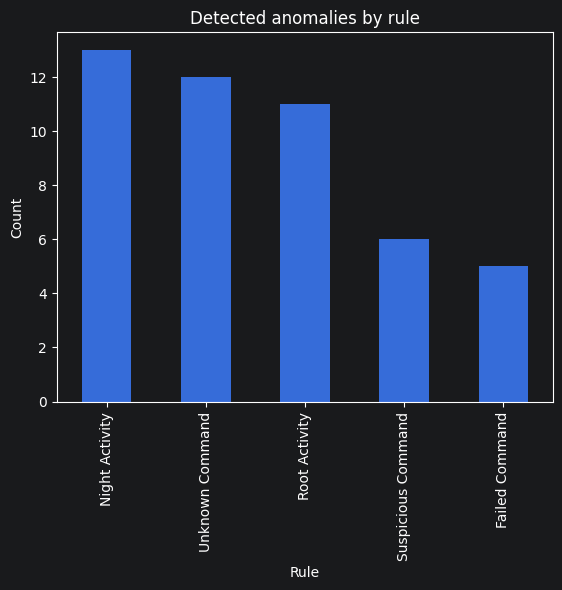

In [7]:
import matplotlib.pyplot as plt

df["rule"].value_counts().plot.bar()

plt.title("Detected anomalies by rule")
plt.xlabel("Rule")
plt.ylabel("Count")

plt.show()

# 7 Wykres kołowy

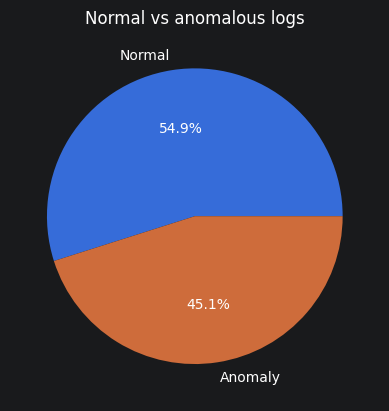

In [8]:
normal_logs = total_logs - anomaly_logs

plt.pie(
    [stats["normal_logs"], stats["anomaly_logs"]],
    labels=["Normal", "Anomaly"],
    autopct="%1.1f%%"
)

plt.title("Normal vs anomalous logs")

plt.show()

In [9]:
ATTACK_COMMANDS = {
    "hydra",
    "nmap",
    "nc",
    "netcat"
}

from src.preprocessing import calculate_baseline_metrics

metrics = calculate_baseline_metrics(records)

metrics

{'tp': 6,
 'fp': 17,
 'tn': 28,
 'fn': 0,
 'accuracy': 66.67,
 'precision': 26.09,
 'recall': 100.0,
 'f1': 41.38}

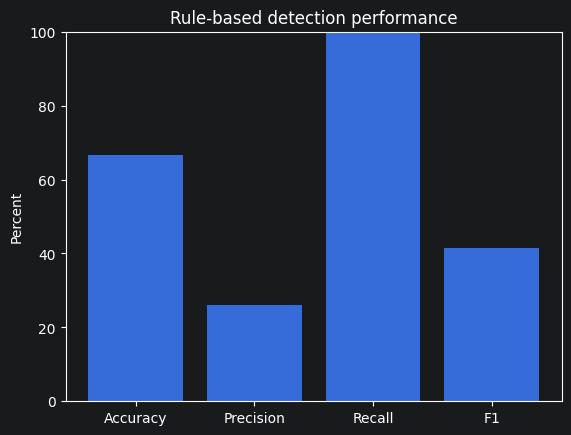

In [10]:
import matplotlib.pyplot as plt

labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

values = [
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1"]
]

plt.bar(labels, values)

plt.ylim(0, 100)

plt.title(
    "Rule-based detection performance"
)

plt.ylabel("Percent")

plt.show()